# Image Dataset Pipelines with torchvision Transforms

Builds a complete image loading and augmentation pipeline using torchvision Datasets, DataLoader, and Compose transforms. Covers normalization, random cropping, flipping, and custom transforms.

In [0]:
# These are the libraries will be used for this lab.

import torch
from torch.utils.data import Dataset
torch.manual_seed(1)

Download the dataset and unzip the files in your data directory, **to download faster this dataset has only 100 samples**:

In [0]:
! wget https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/datasets/img.tar.gz -P /home/ach/Pytorch_Tut/PyTorch_course_data


--2020-03-14 14:40:05--  https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/datasets/img.tar.gz
Resolving s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)... 67.228.254.196
Connecting to s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)|67.228.254.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50460 (49K) [application/octet-stream]
Saving to: ‘/home/ach/Pytorch_Tut/PyTorch_course_data/img.tar.gz’

img.tar.gz          100%[===================>]  49.28K   314KB/s    in 0.2s    

2020-03-14 14:40:06 (314 KB/s) - ‘/home/ach/Pytorch_Tut/PyTorch_course_data/img.tar.gz’ saved [50460/50460]



In [0]:
!tar -xf /home/ach/Pytorch_Tut/PyTorch_course_data/img.tar.gz 

In [0]:
!wget https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/datasets/index.csv 

--2020-03-14 14:40:54--  https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/datasets/index.csv
Resolving s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)... 67.228.254.196
Connecting to s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)|67.228.254.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1680905 (1.6M) [text/csv]
Saving to: ‘index.csv.1’

index.csv.1         100%[===================>]   1.60M  1.21MB/s    in 1.3s    

2020-03-14 14:40:57 (1.21 MB/s) - ‘index.csv.1’ saved [1680905/1680905]



In [0]:
def show_data(data_sample, shape = (28, 28)):
    plt.imshow(data_sample[0].numpy().reshape(shape), cmap='gray')
    plt.title('y = ' + data_sample[1])

The following are the libraries we are going to use for this lab. The `torch.manual_seed()` is for forcing the random function to give the same number every time we try to recompile it.

In [0]:
from matplotlib.pyplot import imshow
import matplotlib.pylab as plt
from PIL import Image
import pandas as pd
import os

## Auxiliary Functions
You will use the following function as components of a dataset object, in this section, you will review each of the components independently.

The path to the csv file with the labels for each image.

In [0]:
# Read CSV file from the URL and print out the first five samples
directory=""
csv_file ='index.csv'
csv_path=os.path.join(directory,csv_file)

In [0]:
data_name = pd.read_csv(csv_path)
data_name.head()

NameError: name 'pd' is not defined

In [0]:
# Get the value on location row 0, column 1 (Notice that index starts at 0)
#rember this dataset has only 100 samples to make the download faster  
print('File name:', data_name.iloc[0, 1])

File name: img/fashion0.png


In [0]:
# Get the value on location row 0, column 0 (Notice that index starts at 0.)

print('y:', data_name.iloc[0, 0])

y: Ankle boot


In [0]:
# Print out the file name and the class number of the element on row 1 (the second row)

print('File name:', data_name.iloc[5999, 1])
print('class or y:', data_name.iloc[5999, 0])

File name: img/fashion5999.png
class or y: T-shirt


In [0]:
# Print out the total number of rows in traing dataset

print('The number of rows: ', data_name.shape[0])

The number of rows:  60000


Load Image
To load the image, you need the directory and the image name. You can concatenate the variable train_data_dir with the name of the image stored in a Dataframe. Finally, you will store the result in the variable image_name

In [0]:
# Combine the directory path with file name

image_name =data_name.iloc[1, 1]
image_name

'img/fashion1.png'

In [0]:
image_path=os.path.join(directory,image_name)
image_path

'img/fashion1.png'

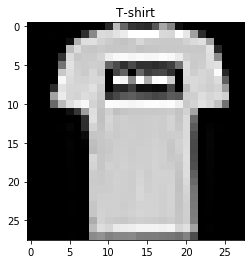

In [0]:
# Plot the second training image

image = Image.open(image_path)
plt.imshow(image,cmap='gray', vmin=0, vmax=255)
plt.title(data_name.iloc[1, 0])
plt.show()

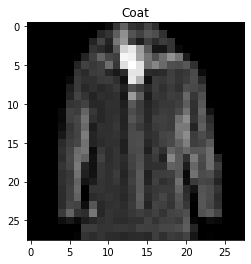

In [0]:
# Plot the 20th image

image_name = data_name.iloc[19, 1]
image_path=os.path.join(directory,image_name)
image = Image.open(image_path)
plt.imshow(image,cmap='gray', vmin=0, vmax=255)
plt.title(data_name.iloc[19, 0])
plt.show()

## Create a Dataset Class
In this section, we will use the components in the last section to build a dataset class and then create an object.

In [0]:
os.getcwd()

'/home/ach/Pytorch_Tut'

In [0]:
# Create your own dataset object

class Dataset(Dataset):

    # Constructor
    def __init__(self, csv_file, data_dir, transform=None):
        
        # Image directory
        self.data_dir=data_dir
        
        # The transform is goint to be used on image
        self.transform = transform
        data_dircsv_file=os.path.join(self.data_dir,csv_file)
        # Load the CSV file contians image info
        self.data_name= pd.read_csv(data_dircsv_file)
        
        # Number of images in dataset
        self.len=self.data_name.shape[0] 
    
    # Get the length
    def __len__(self):
        return self.len
    
    # Getter
    def __getitem__(self, idx):
        
        # Image file path
        img_name=os.path.join(self.data_dir,self.data_name.iloc[idx, 1])
        # Open image file
        image = Image.open(img_name)
        
        # The class label for the image
        y = self.data_name.iloc[idx, 0]
        
        # If there is any transform method, apply it onto the image
        if self.transform:
            image = self.transform(image)

        return image, y

In [0]:
# Create the dataset objects

dataset = Dataset(csv_file=csv_file, data_dir=directory)

Each sample of the image and the class y is stored in a tuple  `dataset[sample]` . The image is the first element in the tuple  `dataset[sample][0]` the label or class is the second element in the tuple  `dataset[sample][1]`. For example you can plot the first image and class.

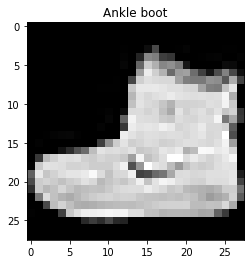

In [0]:
image=dataset[0][0]
y=dataset[0][1]

plt.imshow(image,cmap='gray', vmin=0, vmax=255)
plt.title(y)
plt.show()

In [0]:
y

'Ankle boot'

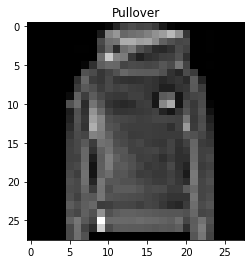

In [0]:
image=dataset[54][0]
y=dataset[54][1]

plt.imshow(image,cmap='gray', vmin=0, vmax=255)
plt.title(y)
plt.show()

## Torchvision Transforms 
You will focus on the following libraries:

In [0]:
import torchvision.transforms as transforms

We can apply some image transform functions on the dataset object. The image can be cropped and converted to a tensor. We can use `transform.Compose` we learned from the previous lab to combine the two transform functions.

In [0]:
# Combine two transforms: crop and convert to tensor. Apply the compose to MNIST dataset

croptensor_data_transform = transforms.Compose([transforms.CenterCrop(20), transforms.ToTensor()])
dataset = Dataset(csv_file=csv_file , data_dir=directory,transform=croptensor_data_transform )
print("The shape of the first element tensor: ", dataset[0][0].shape)

The shape of the first element tensor:  torch.Size([1, 20, 20])


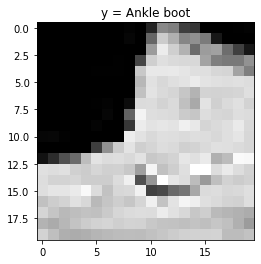

In [0]:
# Plot the first element in the dataset

show_data(dataset[0],shape = (20, 20))

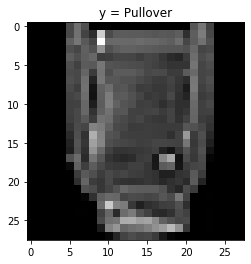

In [0]:
# Construct the compose. Apply it on MNIST dataset. Plot the image out.

fliptensor_data_transform = transforms.Compose([transforms.RandomVerticalFlip(p=1),transforms.ToTensor()])
dataset = Dataset(csv_file=csv_file , data_dir=directory,transform=fliptensor_data_transform )
show_data(dataset[54])

Try to use the `RandomHorizontalFlip` (horizontally flip the image) with vertically flip and convert to tensor as a compose. Apply the compose on image. Use show_data() to plot the second image (the image as 2).

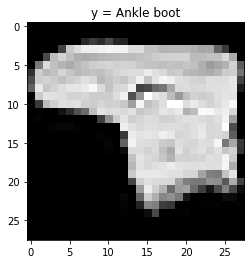

In [0]:
my_data_transform = transforms.Compose([transforms.RandomVerticalFlip(p = 1), 
                                        transforms.RandomHorizontalFlip(p = 1), transforms.ToTensor()])
dataset = Dataset(csv_file=csv_file , data_dir=directory,transform=fliptensor_data_transform )
show_data(dataset[0])